In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [61]:
final_df = pd.read_csv('/content/data_clean.csv')

In [66]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262709 entries, 0 to 262708
Data columns (total 89 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      262709 non-null  object 
 1   store_nbr                 262709 non-null  int64  
 2   item_nbr                  262709 non-null  int64  
 3   units                     262709 non-null  float64
 4   station_nbr               262709 non-null  float64
 5   tmax                      262709 non-null  float64
 6   tmin                      262709 non-null  float64
 7   tavg                      262709 non-null  float64
 8   depart                    262709 non-null  float64
 9   dewpoint                  262709 non-null  float64
 10  wetbulb                   262709 non-null  float64
 11  heat                      262709 non-null  float64
 12  cool                      262709 non-null  float64
 13  snowfall                  262709 non-null  f

In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.0 MB/s eta 0:00:00


In [70]:
final_df = final_df.drop(columns=['date', 'station_nbr'])

In [67]:
weather_columns = [
    'BCFG', 'BLDU', 'BLSN', 'BR', 'DU', 'DZ', 'FG', 'FG+', 'FU', 'FZDZ', 'FZFG', 'FZRA',
    'GR', 'GS', 'HZ', 'MIFG', 'PL', 'PRFG', 'RA', 'SG', 'SN', 'SQ', 'TS', 'TSRA',
    'TSSN', 'UP', 'VCFG', 'VCTS'
]

final_df[weather_columns] = final_df[weather_columns] == 'True'

In [69]:
final_df['id'] = pd.Categorical(final_df['id'])

In [68]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262709 entries, 0 to 262708
Data columns (total 89 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date                      262709 non-null  object 
 1   store_nbr                 262709 non-null  int64  
 2   item_nbr                  262709 non-null  int64  
 3   units                     262709 non-null  float64
 4   station_nbr               262709 non-null  float64
 5   tmax                      262709 non-null  float64
 6   tmin                      262709 non-null  float64
 7   tavg                      262709 non-null  float64
 8   depart                    262709 non-null  float64
 9   dewpoint                  262709 non-null  float64
 10  wetbulb                   262709 non-null  float64
 11  heat                      262709 non-null  float64
 12  cool                      262709 non-null  float64
 13  snowfall                  262709 non-null  f

In [83]:
column_names = final_df.columns.tolist()
column_names

['store_nbr',
 'item_nbr',
 'units',
 'tmax',
 'tmin',
 'tavg',
 'depart',
 'dewpoint',
 'wetbulb',
 'heat',
 'cool',
 'snowfall',
 'preciptotal',
 'sealevel',
 'resultspeed',
 'resultdir',
 'avgspeed',
 'BCFG',
 'BLDU',
 'BLSN',
 'BR',
 'DU',
 'DZ',
 'FG',
 'FG+',
 'FU',
 'FZDZ',
 'FZFG',
 'FZRA',
 'GR',
 'GS',
 'HZ',
 'MIFG',
 'PL',
 'PRFG',
 'RA',
 'SG',
 'SN',
 'SQ',
 'TS',
 'TSRA',
 'TSSN',
 'UP',
 'VCFG',
 'VCTS',
 'id',
 'filled',
 'weekend',
 '_fri',
 '_mon',
 '_sat',
 '_sun',
 '_thu',
 '_tue',
 '_wed',
 'month_apr',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'season_autumn',
 'season_spring',
 'season_summer',
 'season_winter',
 'day_of_year',
 'temperature_diff',
 'heavy_precip',
 'max_temp_last_3_days',
 'avg_temp_last_3_days',
 'avg_precip_last_3_days',
 'avg_sealevel_last_3_days',
 'avg_speed_last_3_days',
 'is_holiday',
 'avg_daily_sales_item',
 'store_sales_ran

In [93]:
final_df.to_csv("data_model.csv", index=False)

0:	learn: 36.4867638	test: 43.5772702	best: 43.5772702 (0)	total: 74.6ms	remaining: 3m 36s
100:	learn: 19.7033568	test: 25.4634788	best: 25.4634788 (100)	total: 7.28s	remaining: 3m 21s
200:	learn: 14.7477540	test: 19.4187052	best: 19.4187052 (200)	total: 14.5s	remaining: 3m 14s
300:	learn: 13.4973078	test: 17.4366671	best: 17.4366671 (300)	total: 21.9s	remaining: 3m 8s
400:	learn: 13.0996045	test: 16.7123400	best: 16.7123400 (400)	total: 29.1s	remaining: 3m 1s
500:	learn: 12.8829337	test: 16.4275211	best: 16.4275211 (500)	total: 36.6s	remaining: 2m 55s
600:	learn: 12.7184866	test: 16.2584334	best: 16.2584334 (600)	total: 43.6s	remaining: 2m 46s
700:	learn: 12.5833789	test: 16.1562164	best: 16.1562164 (700)	total: 51s	remaining: 2m 39s
800:	learn: 12.4578527	test: 16.0834017	best: 16.0832235 (798)	total: 58s	remaining: 2m 32s
900:	learn: 12.3331553	test: 16.0222941	best: 16.0222941 (900)	total: 1m 5s	remaining: 2m 25s
1000:	learn: 12.2231002	test: 15.9794884	best: 15.9783001 (998)	total

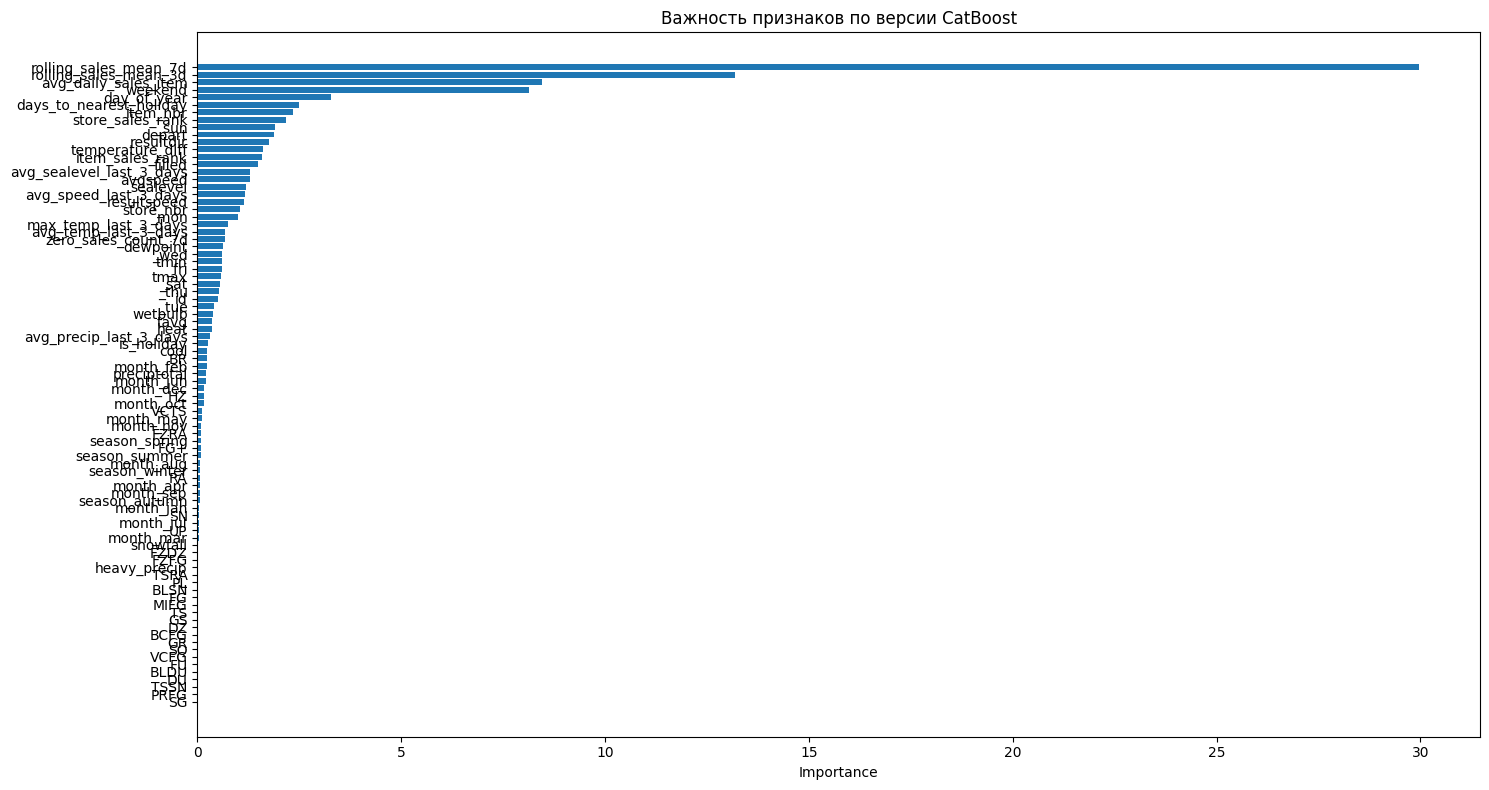

In [96]:
from catboost import CatBoostRegressor, cv, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#Категориальные признаки
cat_features = ['id']

#Подготовка данных
features = column_names[:2] + column_names[3:]
X = final_df[features]
y = final_df['units']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, shuffle=False)


final_model = CatBoostRegressor(
    depth=10,
    learning_rate=0.009,
    l2_leaf_reg=4,
    iterations=2900,
    loss_function='RMSE',
    cat_features=cat_features,
    random_seed=1,
    verbose=100
)

final_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=200,
    verbose=100
)

y_pred = final_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"🔍 RMSE на тесте: {rmse:.4f}")
print(f"📈 R² на тесте: {r2:.4f}")


importances = final_model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)


plt.figure(figsize=(15, 8))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Важность признаков по версии CatBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

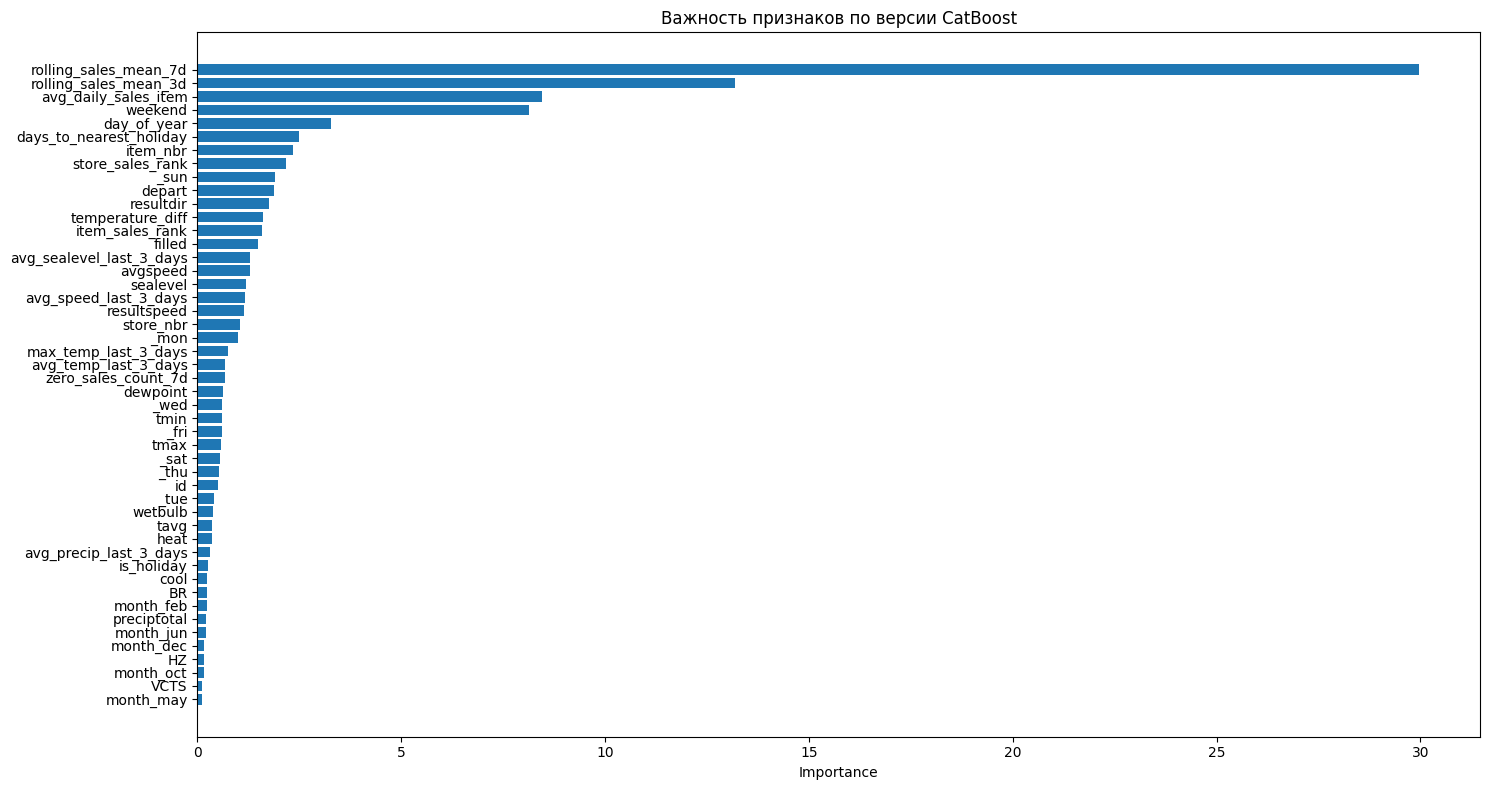

In [105]:
#Определяем список признаков, чья важность хоть сколько-то значительна
importances = final_model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)
most_important_features = feature_importance_df[feature_importance_df['importance']>0.1]

#визуализируем степень важности признаков из списка "избранных"
plt.figure(figsize=(15, 8))
plt.barh(most_important_features["feature"], most_important_features["importance"])
plt.gca().invert_yaxis()
plt.title("Важность признаков по версии CatBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [99]:
final_model.save_model('catboost_best_model_2.cbm')